# Tema 4 - Análisis de la Respuesta Frecuencial

**Fundamentos de Control - GIERM**

---

## Objetivos de aprendizaje

- Comprender el concepto de respuesta frecuencial: cómo un sistema lineal modifica la amplitud y fase de una señal sinusoidal
- Construir diagramas de Bode (magnitud y fase) a partir de los bloques básicos: ganancia, integrador, polos y ceros reales, polos complejos
- Dibujar diagramas de Bode asintóticos y compararlos con la curva real
- Trazar diagramas de Nyquist e interpretar su significado
- Analizar el efecto del retardo puro en la respuesta frecuencial
- Identificar las frecuencias de cruce de ganancia y de fase

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - asíntotas, límites
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados
COLOR_FASE = '#6a3d9a'        # violeta - curvas de fase
COLOR_ASINTOTA = '#ff7f00'    # naranja - asíntotas

print('Configuración lista.')

Configuración lista.


---

## 1. Concepto de respuesta frecuencial

Cuando aplicamos una **entrada sinusoidal** $u(t) = A \sin(\omega t)$ a un sistema lineal e invariante en el tiempo (LTI) con función de transferencia $G(s)$, la **salida en régimen permanente** es también una sinusoide de la misma frecuencia, pero con amplitud y fase modificadas:

$$\boxed{y_{ss}(t) = A \cdot |G(j\omega)| \cdot \sin\!\big(\omega t + \angle G(j\omega)\big)}$$

Donde:
- $|G(j\omega)|$ es la **magnitud** de la función de transferencia evaluada en $s = j\omega$ $\to$ factor de escala de la amplitud
- $\angle G(j\omega)$ es la **fase** $\to$ desfase entre entrada y salida

**Idea clave:** La respuesta frecuencial describe *cómo el sistema filtra cada frecuencia*. Frecuencias que el sistema amplifica tendrán $|G(j\omega)| > 1$; las que atenúa, $|G(j\omega)| < 1$.

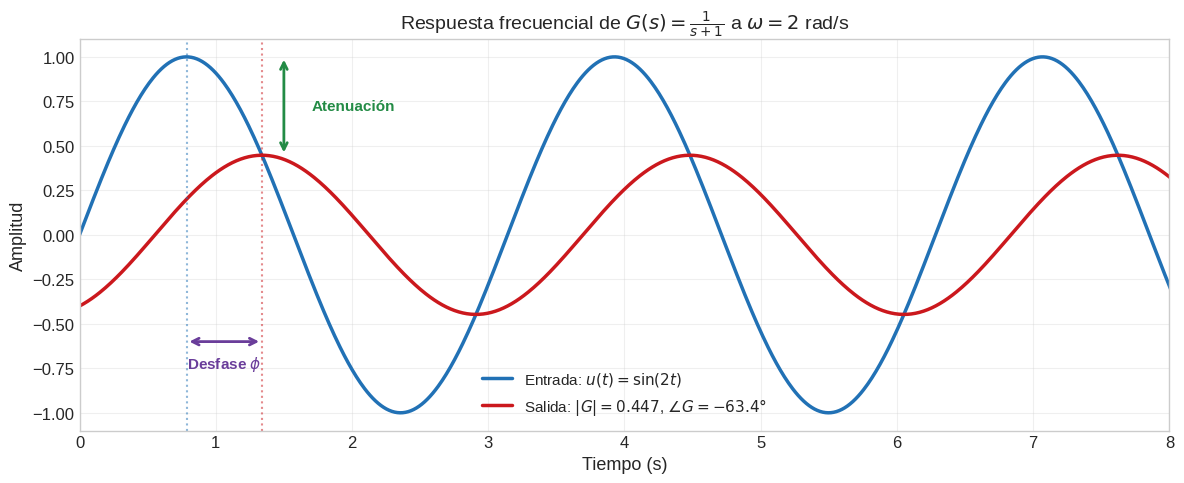

In [2]:
# Ejemplo: entrada sinusoidal vs salida de G(s) = 1/(s+1) a w = 2 rad/s
t = np.linspace(0, 10, 1000)
omega = 2.0
A_in = 1.0

# G(jw) = 1/(jw+1)
G_jw = 1.0 / (1j * omega + 1)
magnitud = np.abs(G_jw)
fase = np.angle(G_jw)  # en radianes

u = A_in * np.sin(omega * t)
y_ss = A_in * magnitud * np.sin(omega * t + fase)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, u, color=COLOR_PRINCIPAL, lw=2.5, label=r'Entrada: $u(t) = \sin(2t)$')
ax.plot(t, y_ss, color=COLOR_RECTA, lw=2.5, label=f'Salida: $|G|={magnitud:.3f}$, $\\angle G={np.degrees(fase):.1f}°$')

# Anotar atenuación
ax.annotate('', xy=(1.5, magnitud), xytext=(1.5, 1.0),
            arrowprops=dict(arrowstyle='<->', color=COLOR_PUNTO, lw=2))
ax.text(1.7, 0.7, r'Atenuación', fontsize=11, color=COLOR_PUNTO, fontweight='bold')

# Anotar desfase
ax.axvline(x=np.pi/(2*omega), color=COLOR_PRINCIPAL, ls=':', alpha=0.5)
t_pico_salida = (np.pi/2 - fase) / omega
ax.axvline(x=t_pico_salida, color=COLOR_RECTA, ls=':', alpha=0.5)
ax.annotate('', xy=(np.pi/(2*omega), -0.6), xytext=(t_pico_salida, -0.6),
            arrowprops=dict(arrowstyle='<->', color=COLOR_FASE, lw=2))
ax.text((np.pi/(2*omega) + t_pico_salida)/2, -0.75, r'Desfase $\phi$',
        fontsize=11, color=COLOR_FASE, fontweight='bold', ha='center')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Amplitud')
ax.set_title(r'Respuesta frecuencial de $G(s) = \frac{1}{s+1}$ a $\omega = 2$ rad/s')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 8])
plt.tight_layout()
plt.show()

---

## 2. Diagrama de Bode: fundamentos

El **diagrama de Bode** consiste en dos gráficas con eje de frecuencia logarítmico:

1. **Magnitud** en decibelios: $20 \log_{10}|G(j\omega)|$ vs $\log \omega$
2. **Fase** en grados: $\angle G(j\omega)$ vs $\log \omega$

**Ventaja clave:** al usar escalas logarítmicas, la multiplicación de funciones de transferencia se convierte en **suma de diagramas individuales**:

$$G(s) = G_1(s) \cdot G_2(s) \implies \begin{cases} |G|_{\text{dB}} = |G_1|_{\text{dB}} + |G_2|_{\text{dB}} \\ \angle G = \angle G_1 + \angle G_2 \end{cases}$$

Esto permite construir el Bode de cualquier sistema **sumando los bloques básicos**.

---

## 3. Bloques básicos del diagrama de Bode

Todo sistema racional se descompone en estos bloques:

| Bloque | Forma | Magnitud | Fase |
|--------|-------|----------|------|
| Ganancia | $K$ | $20\log|K|$ dB (constante) | $0°$ si $K>0$, $-180°$ si $K<0$ |
| Integrador | $\dfrac{1}{s}$ | $-20$ dB/dec | $-90°$ constante |
| Derivador | $s$ | $+20$ dB/dec | $+90°$ constante |
| Polo real | $\dfrac{1}{\tau s + 1}$ | $0$ dB hasta $\omega=1/\tau$, luego $-20$ dB/dec | $0°$ a $-90°$ |
| Cero real | $\tau s + 1$ | $0$ dB hasta $\omega=1/\tau$, luego $+20$ dB/dec | $0°$ a $+90°$ |
| Polos complejos | $\dfrac{1}{s^2/\omega_n^2 + 2\zeta s/\omega_n + 1}$ | Pico de resonancia en $\omega_n$ | $0°$ a $-180°$ |

### 3.1 Ganancia constante $K$

$$G(s) = K$$

- **Magnitud:** línea horizontal a $20 \log_{10}(K)$ dB
- **Fase:** $0°$ (si $K > 0$) o $-180°$ (si $K < 0$)

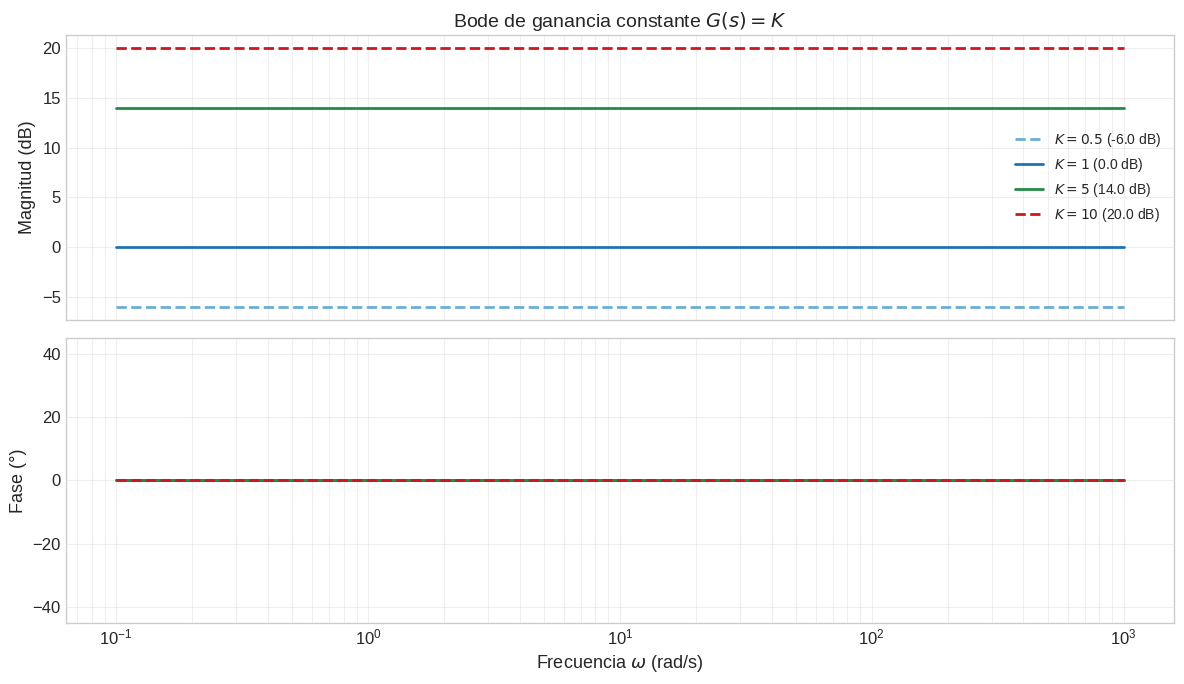

In [3]:
# Bode de ganancia constante K
w = np.logspace(-1, 3, 500)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for K, color, ls in [(0.5, '#6baed6', '--'), (1, COLOR_PRINCIPAL, '-'),
                      (5, COLOR_PUNTO, '-'), (10, COLOR_RECTA, '--')]:
    mag_db = 20 * np.log10(K) * np.ones_like(w)
    fase = np.zeros_like(w)
    ax1.semilogx(w, mag_db, color=color, lw=2, ls=ls, label=f'$K={K}$ ({20*np.log10(K):.1f} dB)')
    ax2.semilogx(w, fase, color=color, lw=2, ls=ls)

ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de ganancia constante $G(s) = K$')
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_ylim([-45, 45])
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Integrador $1/s$ y derivador $s$

$$G(s) = \frac{1}{s} \implies |G(j\omega)|_{\text{dB}} = -20\log_{10}(\omega), \quad \angle G = -90°$$

- La magnitud es una recta con pendiente **$-20$ dB/dec** que pasa por 0 dB en $\omega = 1$ rad/s
- La fase es constante a $-90°$

Para el **derivador** $G(s) = s$: pendiente $+20$ dB/dec, fase $+90°$.

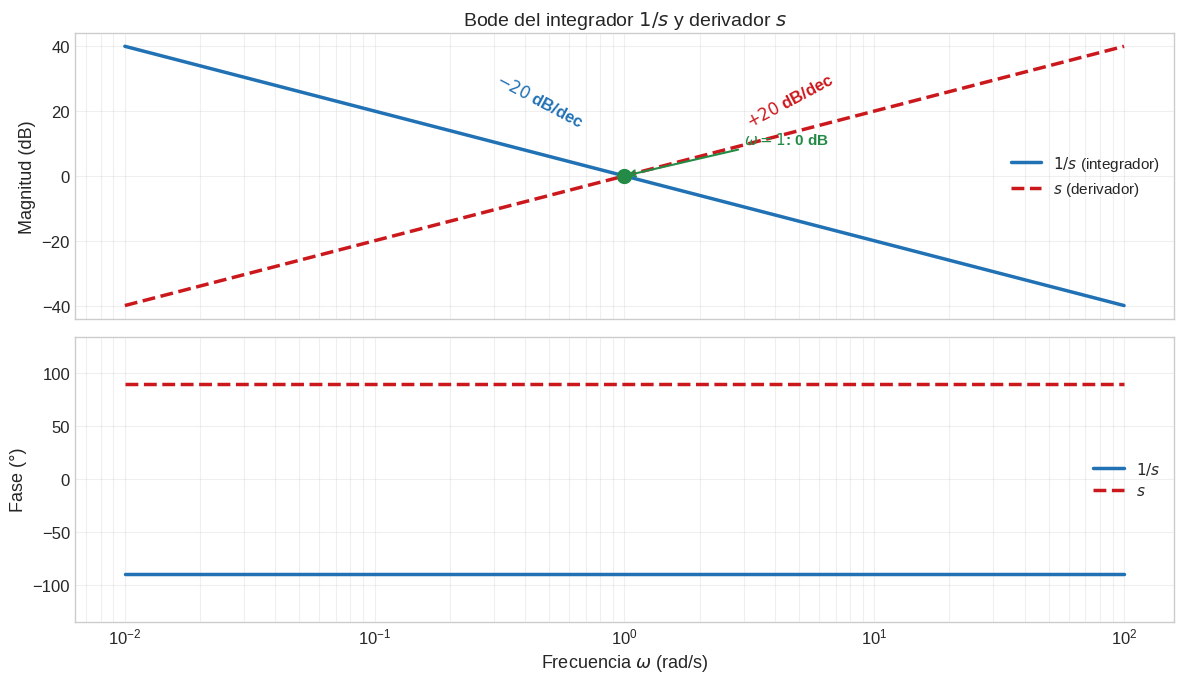

In [4]:
# Bode del integrador 1/s y derivador s
w = np.logspace(-2, 2, 500)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Integrador
mag_int = -20 * np.log10(w)
fase_int = -90 * np.ones_like(w)
ax1.semilogx(w, mag_int, color=COLOR_PRINCIPAL, lw=2.5, label=r'$1/s$ (integrador)')
ax2.semilogx(w, fase_int, color=COLOR_PRINCIPAL, lw=2.5, label=r'$1/s$')

# Derivador
mag_der = 20 * np.log10(w)
fase_der = 90 * np.ones_like(w)
ax1.semilogx(w, mag_der, color=COLOR_RECTA, lw=2.5, ls='--', label=r'$s$ (derivador)')
ax2.semilogx(w, fase_der, color=COLOR_RECTA, lw=2.5, ls='--', label=r'$s$')

# Marcar 0 dB en w=1
ax1.plot(1, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax1.annotate(r'$\omega=1$: 0 dB', xy=(1, 0), xytext=(3, 10),
             fontsize=11, color=COLOR_PUNTO, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

# Anotar pendiente
ax1.text(0.3, 15, r'$-20$ dB/dec', fontsize=12, color=COLOR_PRINCIPAL, fontweight='bold', rotation=-28)
ax1.text(3, 15, r'$+20$ dB/dec', fontsize=12, color=COLOR_RECTA, fontweight='bold', rotation=28)

ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode del integrador $1/s$ y derivador $s$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_ylim([-135, 135])
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Polo real: $G(s) = \dfrac{1}{\tau s + 1}$

La frecuencia de corte (o de esquina) es $\omega_c = 1/\tau$.

**Asíntotas de magnitud:**
- $\omega \ll \omega_c$: $|G| \approx 1$ $\to$ 0 dB
- $\omega \gg \omega_c$: $|G| \approx 1/(\omega\tau)$ $\to$ pendiente $-20$ dB/dec
- En $\omega = \omega_c$: error de la asíntota = $-3$ dB

**Fase:**
- $\omega \ll \omega_c/10$: $\approx 0°$
- $\omega = \omega_c$: $-45°$
- $\omega \gg 10\omega_c$: $\approx -90°$

$$\boxed{|G(j\omega)| = \frac{1}{\sqrt{1 + (\omega\tau)^2}}, \qquad \angle G(j\omega) = -\arctan(\omega\tau)}$$

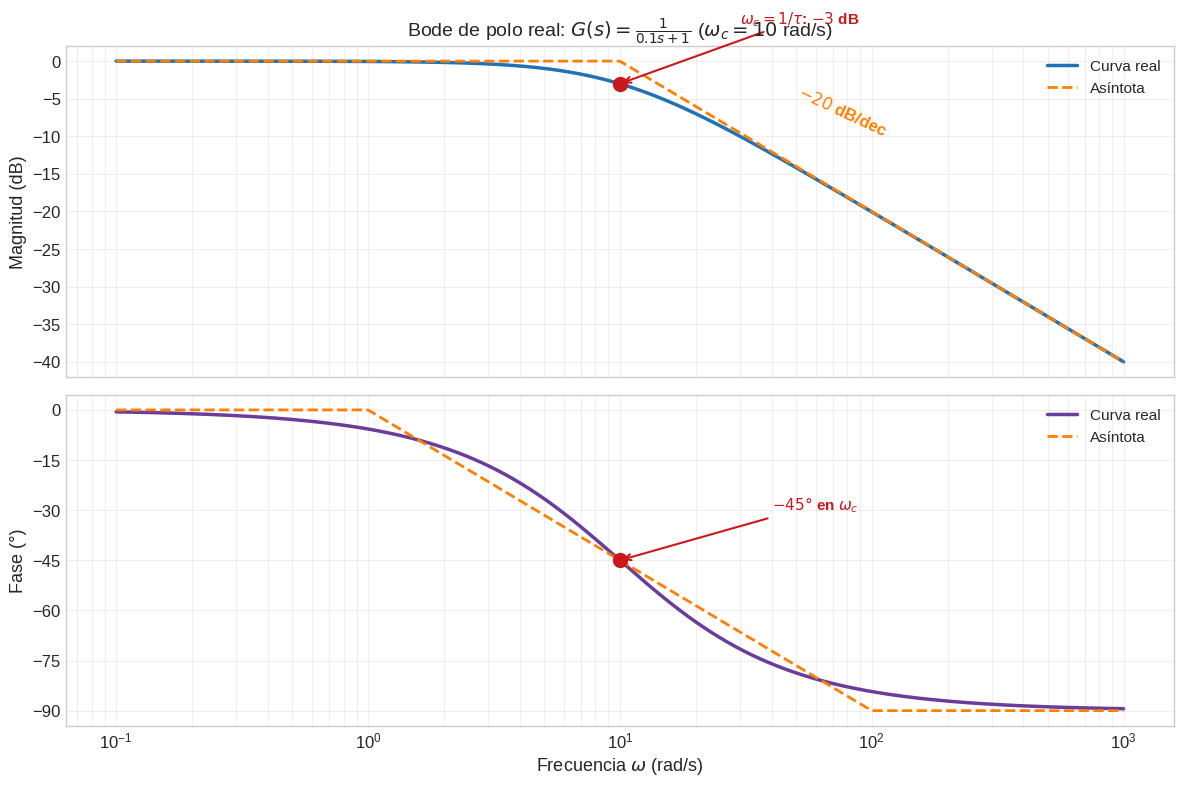

In [5]:
# Bode de polo real 1/(tau*s + 1) con asíntotas
tau = 0.1  # wc = 10 rad/s
wc = 1.0 / tau
sys_polo = signal.TransferFunction([1], [tau, 1])
w = np.logspace(-1, 3, 500)
w_bode, mag_db, fase_deg = signal.bode(sys_polo, w)

# Asíntotas de magnitud
asint_mag = np.where(w_bode <= wc, 0, -20 * np.log10(w_bode / wc))

# Asíntota de fase (aproximación lineal)
asint_fase = np.piecewise(w_bode,
    [w_bode < wc/10, (w_bode >= wc/10) & (w_bode <= wc*10), w_bode > wc*10],
    [0, lambda w: -45 * (1 + np.log10(w/wc)), -90])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Magnitud
ax1.semilogx(w_bode, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_bode, asint_mag, color=COLOR_ASINTOTA, lw=2, ls='--', label=r'Asíntota')
ax1.plot(wc, -3, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax1.annotate(r'$\omega_c = 1/\tau$: $-3$ dB', xy=(wc, -3), xytext=(wc*3, 5),
             fontsize=11, color=COLOR_RECTA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))
ax1.text(50, -10, r'$-20$ dB/dec', fontsize=12, color=COLOR_ASINTOTA, fontweight='bold', rotation=-25)
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de polo real: $G(s) = \frac{1}{0.1s + 1}$ ($\omega_c = 10$ rad/s)')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

# Fase
ax2.semilogx(w_bode, fase_deg, color=COLOR_FASE, lw=2.5, label='Curva real')
ax2.semilogx(w_bode, asint_fase, color=COLOR_ASINTOTA, lw=2, ls='--', label=r'Asíntota')
ax2.plot(wc, -45, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax2.annotate(r'$-45°$ en $\omega_c$', xy=(wc, -45), xytext=(wc*4, -30),
             fontsize=11, color=COLOR_RECTA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_yticks([0, -15, -30, -45, -60, -75, -90])
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Cero real: $G(s) = \tau s + 1$

Es el **inverso del polo real**: las asíntotas y la fase tienen signo contrario.

- $\omega \ll 1/\tau$: 0 dB, fase $\approx 0°$
- $\omega \gg 1/\tau$: pendiente $+20$ dB/dec, fase $\approx +90°$
- En $\omega = 1/\tau$: magnitud $+3$ dB sobre la asíntota, fase $= +45°$

$$\boxed{|G(j\omega)| = \sqrt{1 + (\omega\tau)^2}, \qquad \angle G(j\omega) = +\arctan(\omega\tau)}$$

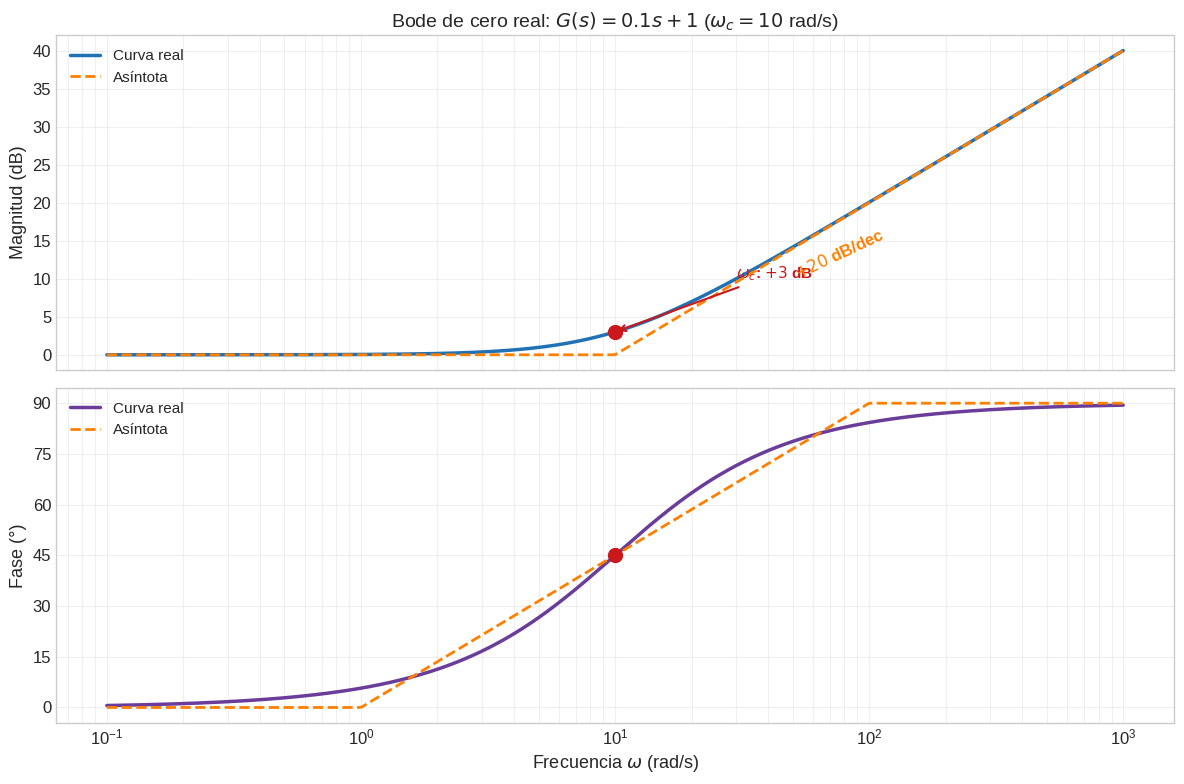

In [6]:
# Bode de cero real (tau*s + 1) con asíntotas
tau = 0.1  # wc = 10 rad/s
wc = 1.0 / tau
sys_cero = signal.TransferFunction([tau, 1], [1])
w = np.logspace(-1, 3, 500)
w_bode, mag_db, fase_deg = signal.bode(sys_cero, w)

# Asíntotas
asint_mag = np.where(w_bode <= wc, 0, 20 * np.log10(w_bode / wc))
asint_fase = np.piecewise(w_bode,
    [w_bode < wc/10, (w_bode >= wc/10) & (w_bode <= wc*10), w_bode > wc*10],
    [0, lambda w: 45 * (1 + np.log10(w/wc)), 90])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.semilogx(w_bode, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_bode, asint_mag, color=COLOR_ASINTOTA, lw=2, ls='--', label=r'Asíntota')
ax1.plot(wc, 3, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax1.annotate(r'$\omega_c$: $+3$ dB', xy=(wc, 3), xytext=(wc*3, 10),
             fontsize=11, color=COLOR_RECTA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))
ax1.text(50, 10, r'$+20$ dB/dec', fontsize=12, color=COLOR_ASINTOTA, fontweight='bold', rotation=25)
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de cero real: $G(s) = 0.1s + 1$ ($\omega_c = 10$ rad/s)')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(w_bode, fase_deg, color=COLOR_FASE, lw=2.5, label='Curva real')
ax2.semilogx(w_bode, asint_fase, color=COLOR_ASINTOTA, lw=2, ls='--', label=r'Asíntota')
ax2.plot(wc, 45, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_yticks([0, 15, 30, 45, 60, 75, 90])
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Polos complejos conjugados

$$G(s) = \frac{1}{\dfrac{s^2}{\omega_n^2} + \dfrac{2\zeta s}{\omega_n} + 1}$$

El comportamiento depende críticamente del **factor de amortiguamiento** $\zeta$:

- $\zeta < 0.707$: aparece un **pico de resonancia** en la magnitud
- $\zeta = 0.707$: la curva pasa suavemente por la frecuencia $\omega_n$ (sin pico)
- $\zeta \to 0$: pico infinito (sistema oscilatorio)

**Asíntotas de magnitud:**
- $\omega \ll \omega_n$: 0 dB
- $\omega \gg \omega_n$: pendiente $-40$ dB/dec (doble polo)

**Fase:** transición de $0°$ a $-180°$ centrada en $\omega_n$, tanto más brusca cuanto menor sea $\zeta$.

$$\boxed{M_r = \frac{1}{2\zeta\sqrt{1 - \zeta^2}}} \quad \text{(pico de resonancia, para } \zeta < 0.707\text{)}$$

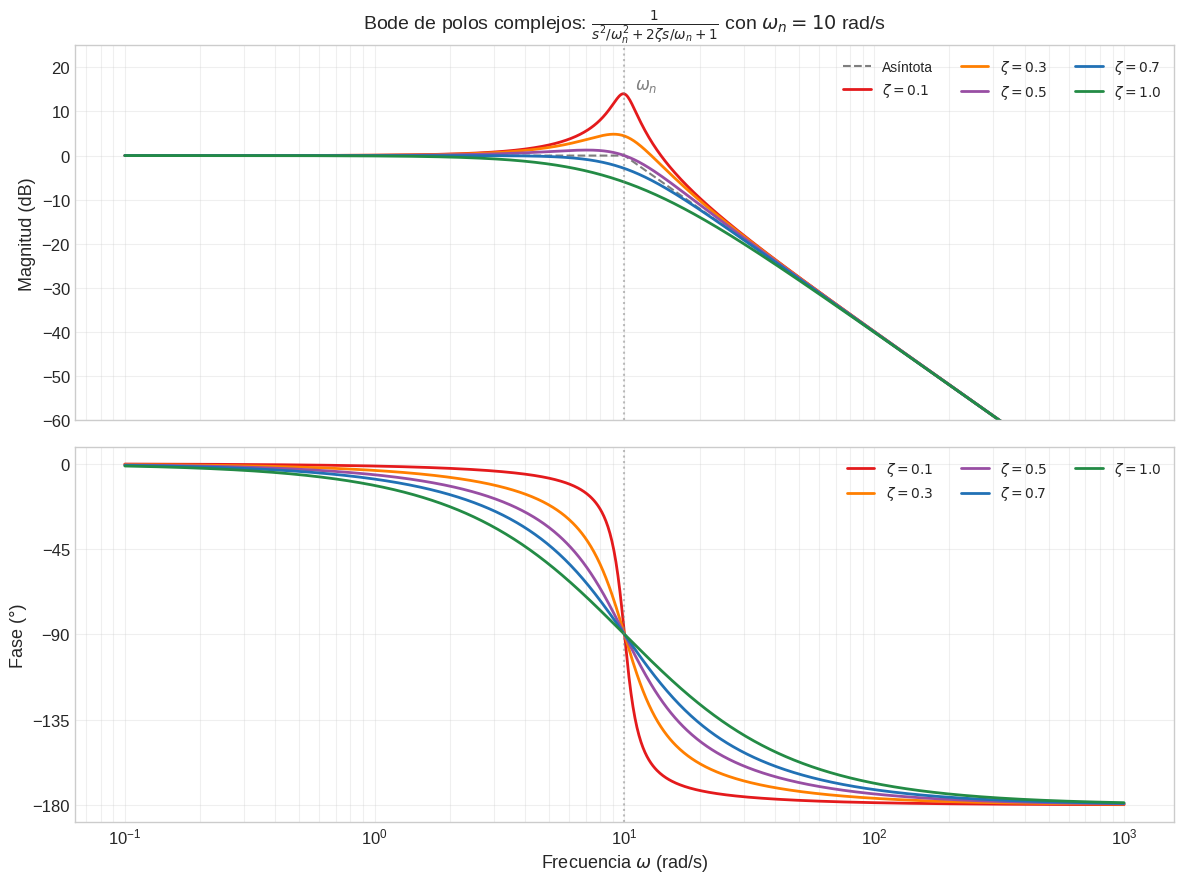

In [7]:
# Bode de polos complejos para distintos valores de zeta
wn = 10.0
w = np.logspace(-1, 3, 1000)
zetas = [0.1, 0.3, 0.5, 0.7, 1.0]
colores_zeta = ['#e41a1c', '#ff7f00', '#984ea3', '#2171b5', '#238b45']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Asíntota
asint = np.where(w <= wn, 0, -40 * np.log10(w / wn))
ax1.semilogx(w, asint, 'k--', lw=1.5, alpha=0.5, label=r'Asíntota')

for zeta, color in zip(zetas, colores_zeta):
    num = [1]
    den = [1/wn**2, 2*zeta/wn, 1]
    sys_comp = signal.TransferFunction(num, den)
    w_b, mag_db, fase_deg = signal.bode(sys_comp, w)
    ax1.semilogx(w_b, mag_db, color=color, lw=2, label=r'$\zeta = ' + f'{zeta}$')
    ax2.semilogx(w_b, fase_deg, color=color, lw=2, label=r'$\zeta = ' + f'{zeta}$')

ax1.axvline(x=wn, color='gray', ls=':', alpha=0.5)
ax1.text(wn*1.1, 15, r'$\omega_n$', fontsize=12, color='gray')
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de polos complejos: $\frac{1}{s^2/\omega_n^2 + 2\zeta s/\omega_n + 1}$ con $\omega_n = 10$ rad/s')
ax1.legend(fontsize=10, ncol=3)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylim([-60, 25])

ax2.axvline(x=wn, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_yticks([0, -45, -90, -135, -180])
ax2.legend(fontsize=10, ncol=3)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Reglas de construcción del Bode asintótico

**Regla de magnitud:**
- Cada **polo** en $\omega_c$ aporta $-20$ dB/dec a partir de $\omega_c$
- Cada **cero** en $\omega_c$ aporta $+20$ dB/dec a partir de $\omega_c$
- Cada **integrador** ($1/s$) aporta $-20$ dB/dec desde el inicio
- La **ganancia** $K$ desplaza toda la curva verticalmente $20\log_{10}(K)$ dB

**Regla de fase:**
- Cada polo aporta $-90°$ (transición centrada en su $\omega_c$, de $\omega_c/10$ a $10\omega_c$)
- Cada cero aporta $+90°$ (misma transición)
- Cada integrador aporta $-90°$ constantes

**Procedimiento:**
1. Poner $G(s)$ en forma estándar (factorizada con $\tau s + 1$)
2. Calcular la ganancia en baja frecuencia
3. Ordenar las frecuencias de corte $\omega_{c_1} < \omega_{c_2} < \cdots$
4. En cada $\omega_{c_i}$, cambiar la pendiente $\pm 20$ dB/dec según sea polo o cero
5. Sumar las contribuciones de fase

---

## 4. Ejemplo completo de construcción de Bode

$$G(s) = \frac{10(s+1)}{s(s+10)(s+100)}$$

**Paso 1: Forma estándar** (factores $\tau s + 1$)

$$G(s) = \frac{10 \cdot 1 \cdot (s+1)}{s \cdot 10 \cdot (0.1s+1) \cdot 100 \cdot (0.01s+1)} = \frac{10}{1000} \cdot \frac{(s+1)}{s \cdot (0.1s+1)(0.01s+1)}$$

$$G(s) = \frac{0.01 \cdot (s+1)}{s \cdot (0.1s+1)(0.01s+1)}$$

**Paso 2: Ganancia estática** $K = 0.01$ $\to$ $20\log_{10}(0.01) = -40$ dB

**Paso 3: Frecuencias de corte** (ordenadas)

| Elemento | Tipo | $\omega_c$ | Efecto en pendiente |
|----------|------|------------|---------------------|
| $1/s$ | Integrador | -- | $-20$ dB/dec desde el inicio |
| $(s+1)$ | Cero | $1$ rad/s | $+20$ dB/dec |
| $1/(0.1s+1)$ | Polo | $10$ rad/s | $-20$ dB/dec |
| $1/(0.01s+1)$ | Polo | $100$ rad/s | $-20$ dB/dec |

**Paso 4: Pendiente acumulada**

| Rango de $\omega$ | Pendiente |
|-------------------|-----------|
| $\omega < 1$ | $-20$ dB/dec (solo integrador) |
| $1 < \omega < 10$ | $-20 + 20 = 0$ dB/dec (cero cancela) |
| $10 < \omega < 100$ | $0 - 20 = -20$ dB/dec |
| $\omega > 100$ | $-20 - 20 = -40$ dB/dec |

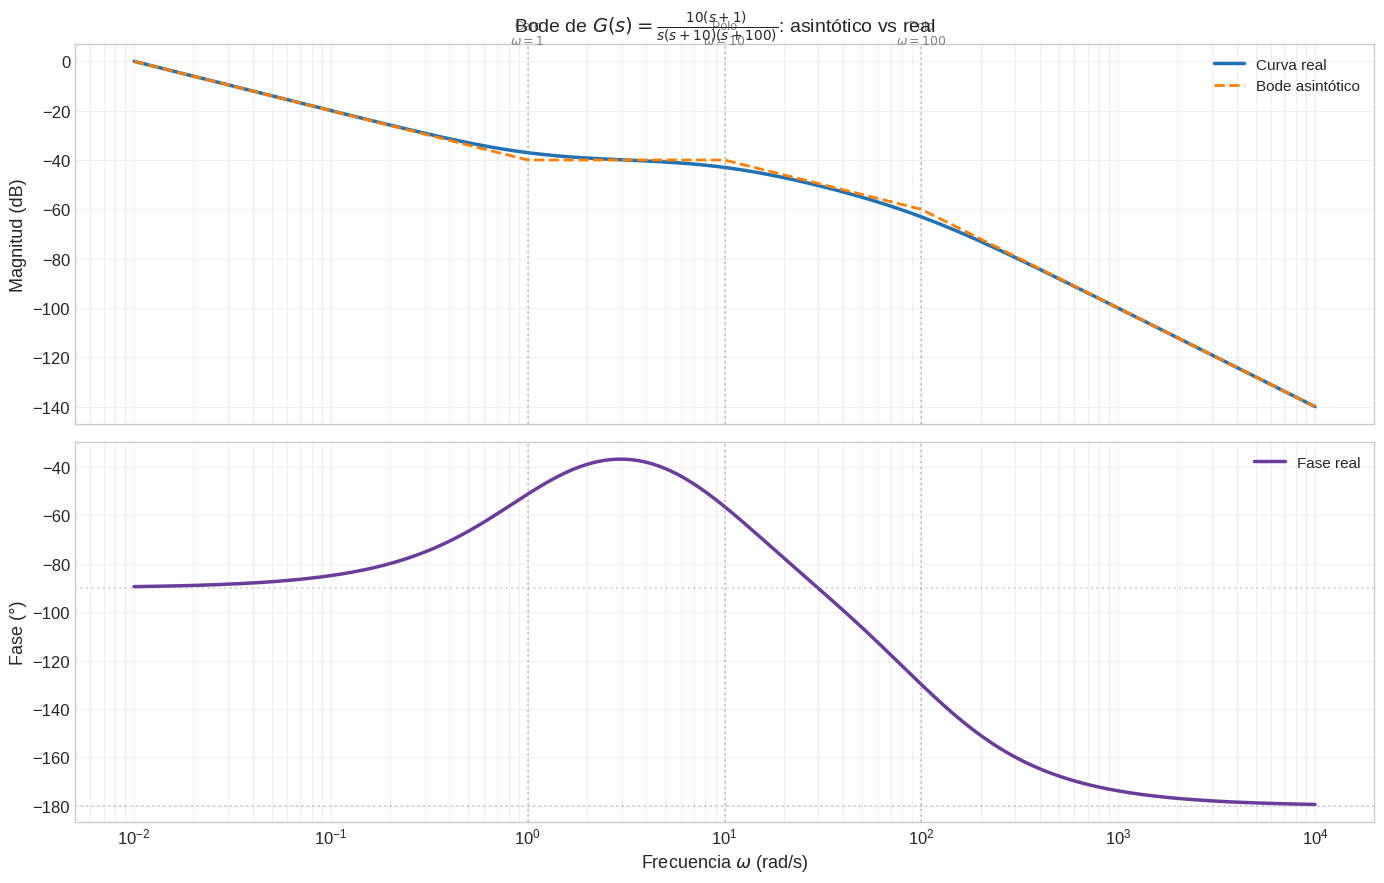

In [8]:
# Bode completo: G(s) = 10(s+1) / [s(s+10)(s+100)]
# Numerador: 10*(s+1) = 10s + 10
# Denominador: s*(s+10)*(s+100) = s*(s^2 + 110s + 1000) = s^3 + 110s^2 + 1000s
num = [10, 10]
den = [1, 110, 1000, 0]  # s^3 + 110s^2 + 1000s
sys_completo = signal.TransferFunction(num, den)

w = np.logspace(-2, 4, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_completo, w)

# Asíntotas de magnitud (construcción manual)
K_db = 20 * np.log10(0.01)  # -40 dB
asint = np.zeros_like(w_b)
for i, wi in enumerate(w_b):
    # Integrador: -20*log10(w) + K_db referido a w=1
    val = K_db - 20 * np.log10(wi)
    # Cero en w=1: +20 dB/dec a partir de w=1
    if wi > 1:
        val += 20 * np.log10(wi / 1)
    # Polo en w=10: -20 dB/dec a partir de w=10
    if wi > 10:
        val -= 20 * np.log10(wi / 10)
    # Polo en w=100: -20 dB/dec a partir de w=100
    if wi > 100:
        val -= 20 * np.log10(wi / 100)
    asint[i] = val

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Magnitud
ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_b, asint, color=COLOR_ASINTOTA, lw=2, ls='--', label='Bode asintótico')

# Marcar frecuencias de corte
for wc, nombre in [(1, 'Cero'), (10, 'Polo'), (100, 'Polo')]:
    ax1.axvline(x=wc, color='gray', ls=':', alpha=0.4)
    ax1.text(wc, ax1.get_ylim()[1] if ax1.get_ylim()[1] else 5, f'{nombre}\n$\\omega={wc}$',
             fontsize=9, ha='center', color='gray')

ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de $G(s) = \frac{10(s+1)}{s(s+10)(s+100)}$: asintótico vs real')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

# Fase
ax2.semilogx(w_b, fase_deg, color=COLOR_FASE, lw=2.5, label='Fase real')
ax2.axhline(y=-90, color='gray', ls=':', alpha=0.3)
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.3)
for wc in [1, 10, 100]:
    ax2.axvline(x=wc, color='gray', ls=':', alpha=0.4)

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Diagrama de Nyquist

El **diagrama de Nyquist** representa $G(j\omega)$ como una curva en el **plano complejo** cuando $\omega$ varía de $0$ a $\infty$.

- Eje horizontal: $\text{Re}\{G(j\omega)\}$
- Eje vertical: $\text{Im}\{G(j\omega)\}$

Cada punto de la curva corresponde a una frecuencia $\omega$. La distancia al origen es $|G(j\omega)|$ y el ángulo es $\angle G(j\omega)$.

**Importancia:** el criterio de estabilidad de Nyquist analiza cuántas veces la curva rodea el punto $(-1, 0)$.

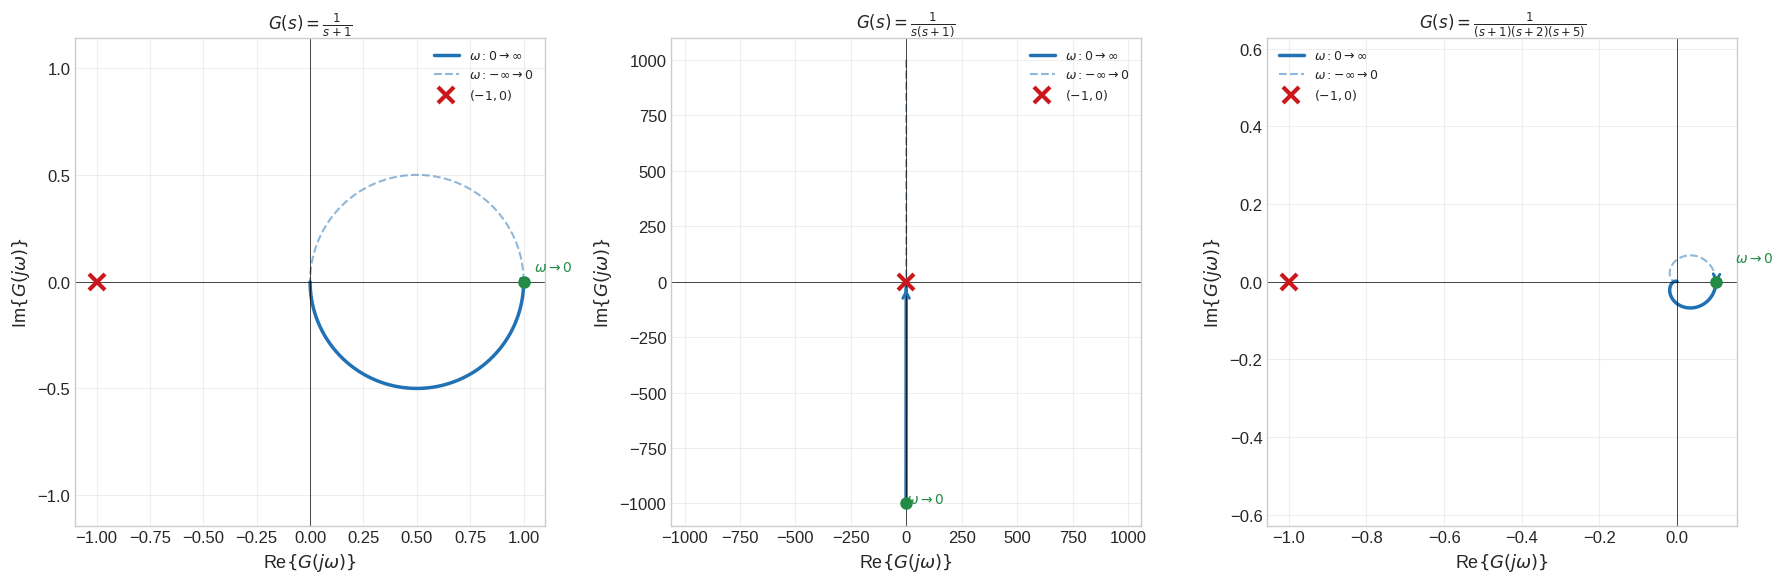

In [9]:
# Nyquist de tres sistemas simples
sistemas = [
    (r'$G(s) = \frac{1}{s+1}$', [1], [1, 1]),
    (r'$G(s) = \frac{1}{s(s+1)}$', [1], [1, 1, 0]),
    (r'$G(s) = \frac{1}{(s+1)(s+2)(s+5)}$', [1], np.polymul(np.polymul([1, 1], [1, 2]), [1, 5]).tolist()),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (titulo, num, den) in zip(axes, sistemas):
    w = np.logspace(-3, 3, 5000)
    sys_i = signal.TransferFunction(num, den)
    w_out, H = signal.freqresp(sys_i, w)
    
    ax.plot(H.real, H.imag, color=COLOR_PRINCIPAL, lw=2.5, label=r'$\omega: 0 \to \infty$')
    ax.plot(H.real, -H.imag, color=COLOR_PRINCIPAL, lw=1.5, ls='--', alpha=0.5,
            label=r'$\omega: -\infty \to 0$')
    
    # Punto (-1, 0)
    ax.plot(-1, 0, 'x', color=COLOR_RECTA, ms=12, mew=3, zorder=5, label='$(-1, 0)$')
    
    # Punto de inicio (w -> 0)
    ax.plot(H.real[0], H.imag[0], 'o', color=COLOR_PUNTO, ms=8, zorder=5)
    ax.annotate(r'$\omega \to 0$', xy=(H.real[0], H.imag[0]),
                xytext=(H.real[0]+0.05, H.imag[0]+0.05), fontsize=10, color=COLOR_PUNTO)
    
    # Flechas de dirección
    mid = len(w) // 4
    ax.annotate('', xy=(H.real[mid+1], H.imag[mid+1]),
                xytext=(H.real[mid], H.imag[mid]),
                arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2))
    
    ax.set_xlabel(r'Re$\{G(j\omega)\}$')
    ax.set_ylabel(r'Im$\{G(j\omega)\}$')
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    ax.axhline(y=0, color='k', lw=0.5)
    ax.axvline(x=0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

---

## 6. Sistemas con retardo puro

Un **retardo puro** de $T$ segundos tiene función de transferencia:

$$G_{\text{retardo}}(s) = e^{-Ts}$$

En frecuencia ($s = j\omega$):

$$\boxed{|e^{-jT\omega}| = 1 \quad (\text{magnitud sin cambio}), \qquad \angle e^{-jT\omega} = -T\omega \;\text{rad} = -\frac{180 T \omega}{\pi}\;°}$$

**Efecto en el Bode:**
- **Magnitud:** no cambia en absoluto
- **Fase:** se resta $T\omega$ radianes (la fase decrece linealmente con $\omega$, cada vez más negativa)

Esto hace que el retardo sea especialmente peligroso para la estabilidad, ya que no afecta la magnitud pero degrada la fase.

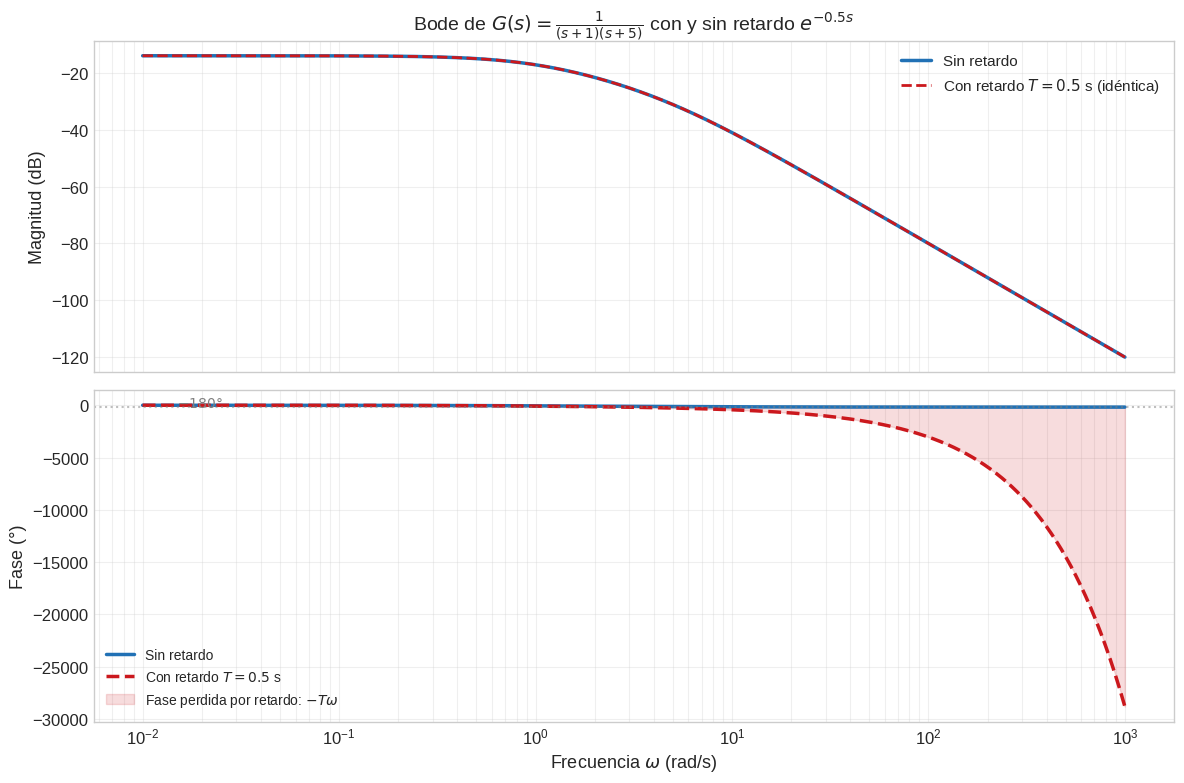

In [10]:
# Bode con y sin retardo: G(s) = 1/[(s+1)(s+5)] con retardo T=0.5s
num = [1]
den = np.polymul([1, 1], [1, 5]).tolist()
sys_base = signal.TransferFunction(num, den)

w = np.logspace(-2, 3, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_base, w)

T_retardo = 0.5  # segundos
fase_retardo = fase_deg - np.degrees(T_retardo * w_b)  # fase adicional del retardo

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Magnitud (idéntica con y sin retardo)
ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Sin retardo')
ax1.semilogx(w_b, mag_db, color=COLOR_RECTA, lw=2, ls='--', label=r'Con retardo $T=0.5$ s (idéntica)')
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Bode de $G(s) = \frac{1}{(s+1)(s+5)}$ con y sin retardo $e^{-0.5s}$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

# Fase (diferente)
ax2.semilogx(w_b, fase_deg, color=COLOR_PRINCIPAL, lw=2.5, label='Sin retardo')
ax2.semilogx(w_b, fase_retardo, color=COLOR_RECTA, lw=2.5, ls='--', label=r'Con retardo $T=0.5$ s')
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.5)
ax2.text(0.015, -175, r'$-180°$', fontsize=10, color='gray')

# Sombrear zona de fase adicional
ax2.fill_between(w_b, fase_deg, fase_retardo, alpha=0.15, color=COLOR_RECTA,
                 label=r'Fase perdida por retardo: $-T\omega$')

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 7. Frecuencias de cruce

Dos frecuencias especialmente importantes para el análisis de estabilidad:

| Concepto | Definición | Símbolo |
|----------|------------|---------|
| **Frecuencia de cruce de ganancia** | $\omega$ donde $|G(j\omega)| = 1$ (0 dB) | $\omega_{cg}$ |
| **Frecuencia de cruce de fase** | $\omega$ donde $\angle G(j\omega) = -180°$ | $\omega_{cf}$ |

**Márgenes de estabilidad:**

$$\boxed{\text{Margen de ganancia (MG)} = -|G(j\omega_{cf})|_{\text{dB}} = -20\log_{10}|G(j\omega_{cf})|}$$

$$\boxed{\text{Margen de fase (MF)} = 180° + \angle G(j\omega_{cg})}$$

- **MG > 0** y **MF > 0**: sistema estable en lazo cerrado
- Para buen comportamiento se recomienda MG $> 6$ dB y MF $> 30°$

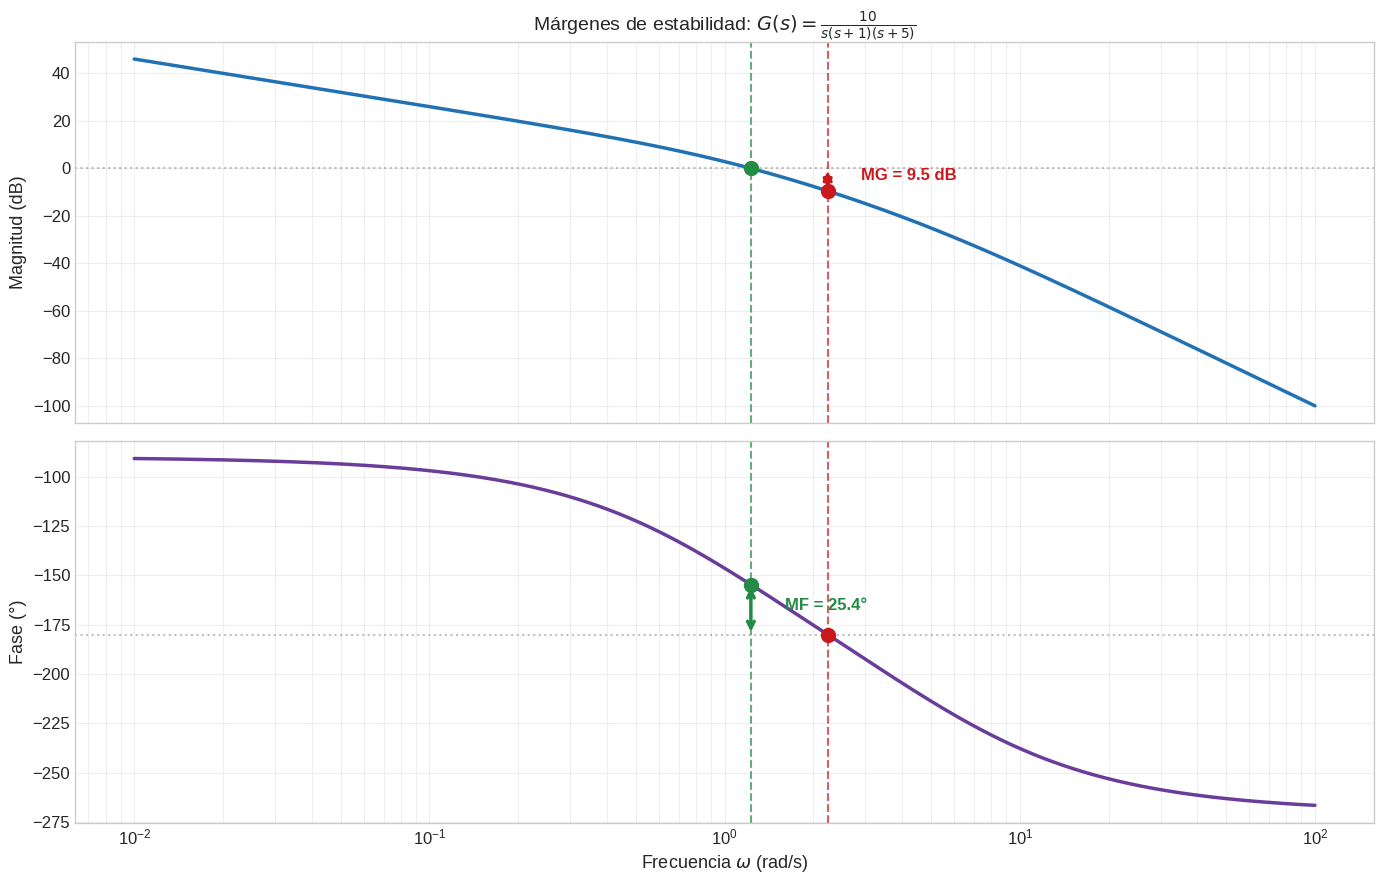

In [11]:
# Márgenes de estabilidad: G(s) = 10 / [s(s+1)(s+5)]
num = [10]
den = np.polymul(np.polymul([1, 0], [1, 1]), [1, 5]).tolist()
sys_mg = signal.TransferFunction(num, den)

w = np.logspace(-2, 2, 2000)
w_b, mag_db, fase_deg = signal.bode(sys_mg, w)

# Encontrar frecuencia de cruce de ganancia (|G| = 0 dB)
idx_cg = np.argmin(np.abs(mag_db))
w_cg = w_b[idx_cg]
fase_en_cg = fase_deg[idx_cg]
MF = 180 + fase_en_cg

# Encontrar frecuencia de cruce de fase (fase = -180°)
idx_cf = np.argmin(np.abs(fase_deg + 180))
w_cf = w_b[idx_cf]
mag_en_cf = mag_db[idx_cf]
MG = -mag_en_cf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Magnitud
ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5)
ax1.axhline(y=0, color='gray', ls=':', alpha=0.5)
ax1.axvline(x=w_cg, color=COLOR_PUNTO, ls='--', alpha=0.7)
ax1.axvline(x=w_cf, color=COLOR_RECTA, ls='--', alpha=0.7)
ax1.plot(w_cg, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax1.plot(w_cf, mag_en_cf, 'o', color=COLOR_RECTA, ms=10, zorder=5)

# Anotar MG
ax1.annotate('', xy=(w_cf, 0), xytext=(w_cf, mag_en_cf),
             arrowprops=dict(arrowstyle='<->', color=COLOR_RECTA, lw=2.5))
ax1.text(w_cf*1.3, mag_en_cf/2, f'MG = {MG:.1f} dB',
         fontsize=12, color=COLOR_RECTA, fontweight='bold')

ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Márgenes de estabilidad: $G(s) = \frac{10}{s(s+1)(s+5)}$')
ax1.grid(True, which='both', alpha=0.3)

# Fase
ax2.semilogx(w_b, fase_deg, color=COLOR_FASE, lw=2.5)
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.5)
ax2.axvline(x=w_cg, color=COLOR_PUNTO, ls='--', alpha=0.7)
ax2.axvline(x=w_cf, color=COLOR_RECTA, ls='--', alpha=0.7)
ax2.plot(w_cg, fase_en_cg, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax2.plot(w_cf, -180, 'o', color=COLOR_RECTA, ms=10, zorder=5)

# Anotar MF
ax2.annotate('', xy=(w_cg, -180), xytext=(w_cg, fase_en_cg),
             arrowprops=dict(arrowstyle='<->', color=COLOR_PUNTO, lw=2.5))
ax2.text(w_cg*1.3, (fase_en_cg - 180)/2, f'MF = {MF:.1f}°',
         fontsize=12, color=COLOR_PUNTO, fontweight='bold')

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8. Ejercicios resueltos

#### Ejercicio resuelto 1: Diagrama de Bode de sistema con polo e integrador

**Enunciado:** Dibujar el diagrama de Bode asintótico y real de $G(s) = \dfrac{5}{s(s+10)}$.

**Paso 1:** Forma estándar

$$G(s) = \frac{5}{s \cdot 10 \cdot (0.1s + 1)} = \frac{0.5}{s(0.1s + 1)}$$

**Paso 2:** Elementos

| Elemento | Tipo | $\omega_c$ |
|----------|------|------------|
| $K = 0.5$ | Ganancia | $20\log(0.5) = -6$ dB |
| $1/s$ | Integrador | $-20$ dB/dec, $-90°$ |
| $1/(0.1s+1)$ | Polo real | $\omega_c = 10$ rad/s |

**Paso 3:** Asíntotas de magnitud
- $\omega < 10$: pendiente $-20$ dB/dec (integrador). En $\omega = 1$: $-6$ dB
- $\omega > 10$: pendiente $-20 - 20 = -40$ dB/dec (integrador + polo)

**Paso 4:** Fase asintótica
- $\omega \ll 1$: $-90°$ (solo integrador)
- $\omega = 10$: $-90° - 45° = -135°$
- $\omega \gg 100$: $-90° - 90° = -180°$

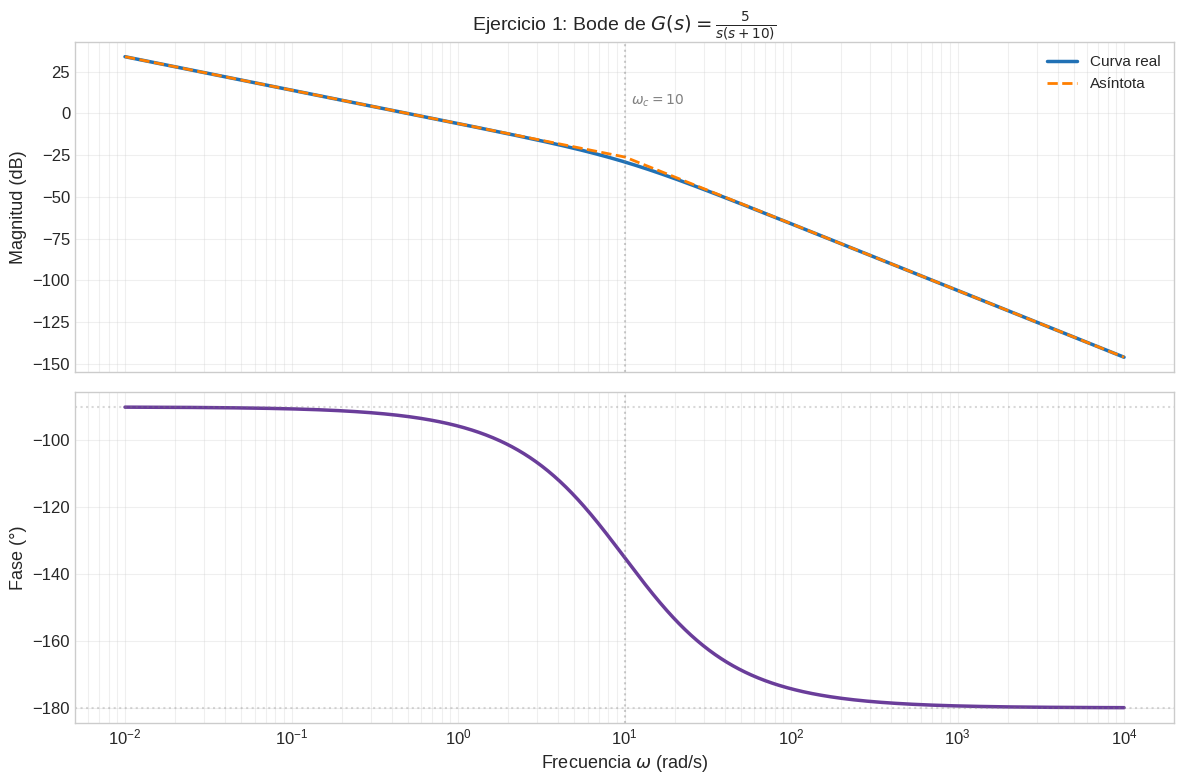

In [12]:
# Ejercicio 1: Bode de G(s) = 5 / [s(s+10)]
num = [5]
den = [1, 10, 0]  # s^2 + 10s
sys_ej1 = signal.TransferFunction(num, den)

w = np.logspace(-2, 4, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_ej1, w)

# Asíntotas manuales
K_db = 20 * np.log10(0.5)  # -6 dB
asint = np.zeros_like(w_b)
for i, wi in enumerate(w_b):
    val = K_db - 20 * np.log10(wi)  # integrador
    if wi > 10:
        val -= 20 * np.log10(wi / 10)  # polo en w=10
    asint[i] = val

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_b, asint, color=COLOR_ASINTOTA, lw=2, ls='--', label='Asíntota')
ax1.axvline(x=10, color='gray', ls=':', alpha=0.4)
ax1.text(11, 5, r'$\omega_c = 10$', fontsize=10, color='gray')
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Ejercicio 1: Bode de $G(s) = \frac{5}{s(s+10)}$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(w_b, fase_deg, color=COLOR_FASE, lw=2.5)
ax2.axhline(y=-90, color='gray', ls=':', alpha=0.3)
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.3)
ax2.axvline(x=10, color='gray', ls=':', alpha=0.4)
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

#### Ejercicio resuelto 2: Calcular $|G(j\omega)|$ y fase a una frecuencia específica

**Enunciado:** Para $G(s) = \dfrac{100}{(s+1)(s+10)}$, calcular $|G(j\omega)|$ y $\angle G(j\omega)$ en $\omega = 5$ rad/s.

**Paso 1:** Sustituir $s = j\omega = j5$

$$G(j5) = \frac{100}{(j5+1)(j5+10)}$$

**Paso 2:** Calcular cada factor

$$j5 + 1 = 1 + j5 \implies |1 + j5| = \sqrt{1^2 + 5^2} = \sqrt{26} \approx 5.099$$

$$\angle(1+j5) = \arctan(5/1) = 78.69°$$

$$j5 + 10 = 10 + j5 \implies |10 + j5| = \sqrt{100 + 25} = \sqrt{125} \approx 11.18$$

$$\angle(10+j5) = \arctan(5/10) = 26.57°$$

**Paso 3:** Magnitud y fase del sistema

$$|G(j5)| = \frac{100}{5.099 \times 11.18} = \frac{100}{57.01} = 1.754$$

$$|G(j5)|_{\text{dB}} = 20\log_{10}(1.754) = 4.88\;\text{dB}$$

$$\boxed{\angle G(j5) = 0° - 78.69° - 26.57° = -105.26°}$$

#### Ejercicio resuelto 3: Identificar $G(s)$ desde Bode asintótico

**Enunciado:** Un diagrama de Bode asintótico tiene las siguientes características:
- Magnitud: comienza con pendiente $-20$ dB/dec, en $\omega = 2$ pasa a $0$ dB/dec, en $\omega = 20$ pasa a $-20$ dB/dec
- En $\omega = 1$, la magnitud es $6$ dB

**Paso 1:** Interpretar las pendientes

- Pendiente inicial $-20$ dB/dec $\to$ hay un **integrador** $1/s$
- En $\omega = 2$: pendiente pasa a $0$ $\to$ se añade $+20$ dB/dec $\to$ hay un **cero** en $\omega = 2$
- En $\omega = 20$: pendiente pasa a $-20$ $\to$ se añade $-20$ dB/dec $\to$ hay un **polo** en $\omega = 20$

**Paso 2:** Forma general

$$G(s) = \frac{K \cdot (s/2 + 1)}{s \cdot (s/20 + 1)}$$

**Paso 3:** Determinar $K$

En $\omega = 1$ (zona de solo integrador): $|G(j1)| = K/1 = K$ $\to$ $20\log(K) = 6$ dB $\to$ $K = 10^{6/20} = 2$

**Resultado:**

$$\boxed{G(s) = \frac{2(0.5s + 1)}{s(0.05s + 1)} = \frac{2(s + 2)}{s(s + 20)}}$$

#### Ejercicio resuelto 4: Diagrama de Nyquist

**Enunciado:** Dibujar el diagrama de Nyquist de $G(s) = \dfrac{2}{(s+1)(s+3)}$.

**Paso 1:** Evaluar en puntos clave

- $\omega = 0$: $G(0) = \dfrac{2}{1 \cdot 3} = \dfrac{2}{3} \approx 0.667$ (punto real, positivo)
- $\omega \to \infty$: $|G| \to 0$, fase $\to -180°$ (se acerca al origen desde el tercer cuadrante)
- $\omega = 1$: $G(j1) = \dfrac{2}{(j+1)(j+3)} = \dfrac{2}{(1+j)(3+j)} = \dfrac{2}{3+j+3j+j^2} = \dfrac{2}{2+4j}$

$$G(j1) = \frac{2}{2+4j} = \frac{2(2-4j)}{(2+4j)(2-4j)} = \frac{4-8j}{4+16} = \frac{4-8j}{20} = 0.2 - 0.4j$$

- $\omega = \sqrt{3}$: $G(j\sqrt{3}) = \dfrac{2}{(j\sqrt{3}+1)(j\sqrt{3}+3)}$

$$= \frac{2}{(1+j\sqrt{3})(3+j\sqrt{3})} = \frac{2}{3 + j\sqrt{3} + 3j\sqrt{3} + j^2 \cdot 3} = \frac{2}{0 + 4j\sqrt{3}} = \frac{2}{4\sqrt{3}\,j} = \frac{-j}{2\sqrt{3}}$$

Esto da un punto puramente imaginario negativo: $(0, -0.289)$.

**Paso 2:** La curva va desde $(0.667, 0)$ hacia abajo (parte imaginaria negativa), cruza el eje imaginario y se acerca al origen.

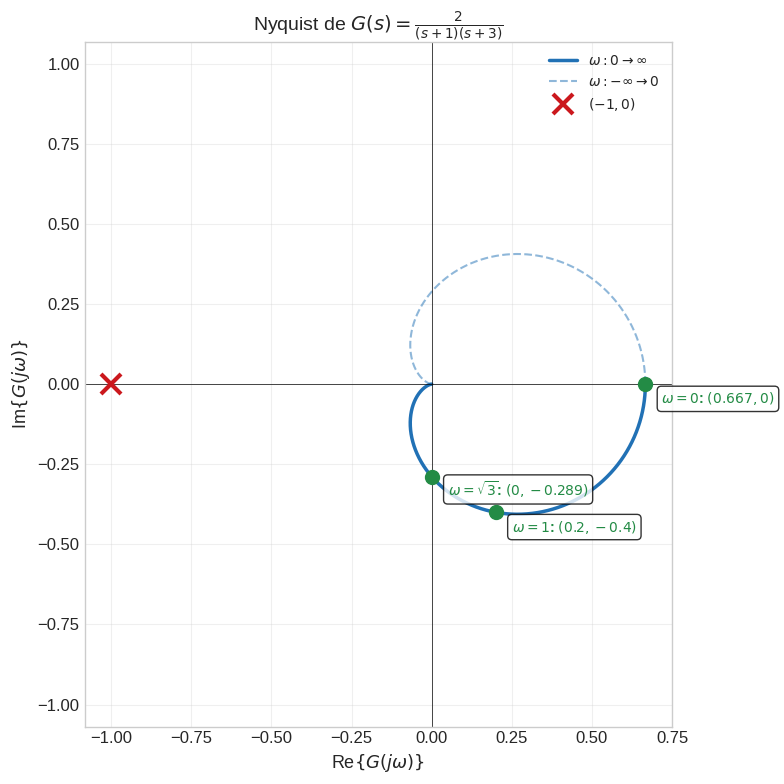

In [13]:
# Ejercicio 4: Nyquist de G(s) = 2/[(s+1)(s+3)]
num = [2]
den = np.polymul([1, 1], [1, 3]).tolist()
sys_ej4 = signal.TransferFunction(num, den)

w = np.logspace(-3, 3, 5000)
w_out, H = signal.freqresp(sys_ej4, w)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(H.real, H.imag, color=COLOR_PRINCIPAL, lw=2.5, label=r'$\omega: 0 \to \infty$')
ax.plot(H.real, -H.imag, color=COLOR_PRINCIPAL, lw=1.5, ls='--', alpha=0.5,
        label=r'$\omega: -\infty \to 0$')

# Puntos calculados
puntos = {
    r'$\omega=0$: $(0.667, 0)$': (2/3, 0),
    r'$\omega=1$: $(0.2, -0.4)$': (0.2, -0.4),
    r'$\omega=\sqrt{3}$: $(0, -0.289)$': (0, -1/(2*np.sqrt(3))),
}

for label, (x, y) in puntos.items():
    ax.plot(x, y, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
    ax.annotate(label, xy=(x, y), xytext=(x+0.05, y-0.06),
                fontsize=10, color=COLOR_PUNTO, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Punto (-1, 0)
ax.plot(-1, 0, 'x', color=COLOR_RECTA, ms=14, mew=3, zorder=5, label='$(-1, 0)$')

ax.set_xlabel(r'Re$\{G(j\omega)\}$')
ax.set_ylabel(r'Im$\{G(j\omega)\}$')
ax.set_title(r'Nyquist de $G(s) = \frac{2}{(s+1)(s+3)}$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')
ax.axhline(y=0, color='k', lw=0.5)
ax.axvline(x=0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

#### Ejercicio resuelto 5: Frecuencia de cruce de ganancia

**Enunciado:** Para $G(s) = \dfrac{20}{s(s+2)(s+10)}$, encontrar la frecuencia de cruce de ganancia $\omega_{cg}$ (donde $|G(j\omega)| = 1$, es decir 0 dB).

**Paso 1:** Calcular $|G(j\omega)|$

$$|G(j\omega)| = \frac{20}{\omega \cdot |j\omega + 2| \cdot |j\omega + 10|} = \frac{20}{\omega \sqrt{\omega^2 + 4} \sqrt{\omega^2 + 100}}$$

**Paso 2:** Igualar a 1

$$\frac{20}{\omega \sqrt{\omega^2 + 4} \sqrt{\omega^2 + 100}} = 1$$

$$\omega^2 (\omega^2 + 4)(\omega^2 + 100) = 400$$

**Paso 3:** Resolución aproximada (tanteo o numérica)

Probemos $\omega = 1.5$:

$$1.5^2 (1.5^2 + 4)(1.5^2 + 100) = 2.25 \times 6.25 \times 102.25 = 1438 \gg 400$$

Probemos $\omega = 0.9$:

$$0.81 \times 4.81 \times 100.81 = 392.7 \approx 400$$

$$\boxed{\omega_{cg} \approx 0.91\;\text{rad/s}}$$

**Paso 4:** Verificación: $|G(j \cdot 0.91)| = \dfrac{20}{0.91 \times \sqrt{4.828} \times \sqrt{100.828}} = \dfrac{20}{0.91 \times 2.197 \times 10.041} \approx \dfrac{20}{20.08} \approx 0.996 \approx 1$ $\checkmark$

#### Ejercicio resuelto 6: Bode de sistema con retardo

**Enunciado:** Dibujar el Bode de $G(s) = \dfrac{e^{-0.2s}}{s + 5}$ y comparar con $G_0(s) = \dfrac{1}{s+5}$ (sin retardo).

**Paso 1:** Sin retardo, tenemos un polo en $\omega_c = 5$ rad/s con $K = 1/5 = 0.2$.

$$|G_0(j\omega)| = \frac{0.2}{\sqrt{1 + (\omega/5)^2}}, \qquad \angle G_0 = -\arctan(\omega/5)$$

**Paso 2:** El retardo $T = 0.2$ s solo afecta la fase:

$$\angle G(j\omega) = \angle G_0(j\omega) - 0.2\omega \;\text{(rad)} = \angle G_0(j\omega) - \frac{0.2 \times 180}{\pi} \omega \;\text{(°)}$$

**Paso 3:** Ejemplo en $\omega = 10$ rad/s:
- Sin retardo: $\angle G_0(j10) = -\arctan(10/5) = -\arctan(2) = -63.43°$
- Retardo adicional: $-0.2 \times 10 = -2$ rad $= -114.59°$
- Total: $-63.43° - 114.59° = -178.02°$ (muy cerca de $-180°$!)

El retardo degrada significativamente la fase a frecuencias altas.

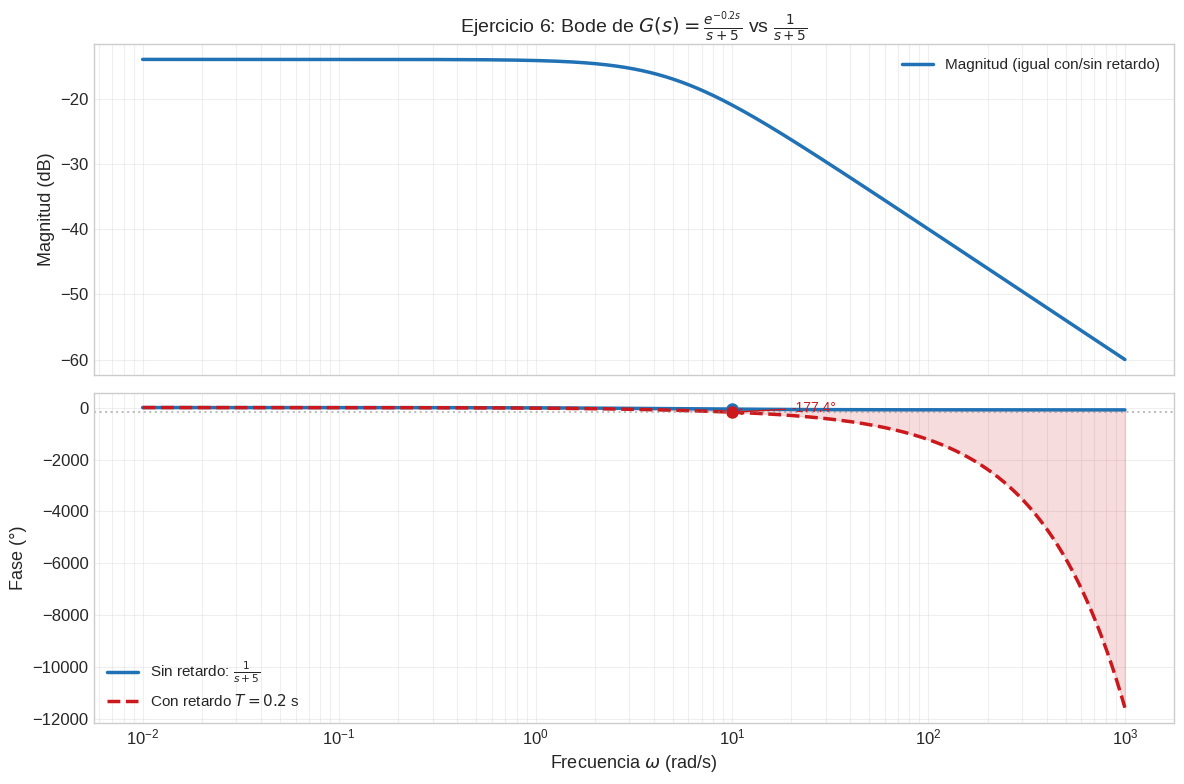

In [14]:
# Ejercicio 6: Bode con retardo vs sin retardo
num = [1]
den = [1, 5]
sys_ej6 = signal.TransferFunction(num, den)

w = np.logspace(-2, 3, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_ej6, w)

T = 0.2
fase_con_retardo = fase_deg - np.degrees(T * w_b)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Magnitud (igual con/sin retardo)')
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Ejercicio 6: Bode de $G(s) = \frac{e^{-0.2s}}{s+5}$ vs $\frac{1}{s+5}$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(w_b, fase_deg, color=COLOR_PRINCIPAL, lw=2.5, label=r'Sin retardo: $\frac{1}{s+5}$')
ax2.semilogx(w_b, fase_con_retardo, color=COLOR_RECTA, lw=2.5, ls='--',
             label=r'Con retardo $T=0.2$ s')
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.5)
ax2.fill_between(w_b, fase_deg, fase_con_retardo, alpha=0.15, color=COLOR_RECTA)

# Marcar punto de w=10
idx_10 = np.argmin(np.abs(w_b - 10))
ax2.plot(10, fase_deg[idx_10], 'o', color=COLOR_PRINCIPAL, ms=8, zorder=5)
ax2.plot(10, fase_con_retardo[idx_10], 'o', color=COLOR_RECTA, ms=8, zorder=5)
ax2.annotate(f'{fase_con_retardo[idx_10]:.1f}°', xy=(10, fase_con_retardo[idx_10]),
             xytext=(20, fase_con_retardo[idx_10]+15), fontsize=10, color=COLOR_RECTA,
             arrowprops=dict(arrowstyle='->', color=COLOR_RECTA))

ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 9. Catálogo completo de ejercicios: todos los patrones

| # | Tipo de ejercicio | Herramienta principal | Dificultad |
|---|-------------------|-----------------------|------------|
| 1 | Dibujar Bode asintótico de $G(s)$ dada | Descomposición en bloques | Media |
| 2 | Dibujar Bode real de $G(s)$ | `scipy.signal.bode` + asíntotas | Media |
| 3 | Calcular $|G(j\omega)|$ a frecuencia dada | Sustitución $s = j\omega$ | Baja |
| 4 | Calcular fase a frecuencia dada | $\angle G(j\omega) = \sum \angle$ factores | Baja |
| 5 | Identificar $G(s)$ desde Bode asintótico | Lectura de pendientes y frecuencias | Alta |
| 6 | Bode de sistema con retardo | Fase $= \angle G_0 - T\omega$ | Media |
| 7 | Diagrama de Nyquist de sistema simple | Evaluar $G(j\omega)$ en plano complejo | Media |
| 8 | Frecuencia de cruce de ganancia $\omega_{cg}$ | $|G(j\omega)| = 1$ | Media |
| 9 | Frecuencia de cruce de fase $\omega_{cf}$ | $\angle G(j\omega) = -180°$ | Media |
| 10 | Margen de ganancia y margen de fase | Combinar $\omega_{cg}$ y $\omega_{cf}$ | Alta |
| 11 | Bode de sistema con polos complejos | Identificar $\zeta$ y $\omega_n$, pico de resonancia | Alta |
| 12 | Bode con múltiples ceros y polos | Construcción paso a paso | Alta |

### 9.1 Tipo 1: Dibujar Bode asintótico

**Método:**
1. Poner $G(s)$ en forma estándar $\dfrac{K \prod (\tau_i s + 1)}{s^n \prod (\tau_j s + 1)}$
2. Calcular ganancia en baja frecuencia: $20\log|K|$ dB
3. Pendiente inicial: $-20n$ dB/dec (por los $n$ integradores)
4. Listar frecuencias de corte $\omega_{c_k} = 1/\tau_k$ de menor a mayor
5. En cada $\omega_{c_k}$: sumar $+20$ dB/dec por cero, $-20$ dB/dec por polo

$$\boxed{\text{Pendiente acumulada} = -20n + 20(\text{n° ceros pasados}) - 20(\text{n° polos pasados}) \;\text{dB/dec}}$$

**Error frecuente:** Olvidar normalizar los factores a la forma $\tau s + 1$ (dividir numerador y denominador para que los términos independientes sean 1).

### 9.2 Tipo 2: Dibujar Bode real

Igual que el Tipo 1, pero además:
- En cada frecuencia de corte de polo: la curva real pasa $-3$ dB por debajo de la asíntota
- En cada frecuencia de corte de cero: la curva real pasa $+3$ dB por encima
- Para polos complejos con $\zeta < 0.707$: hay un pico de resonancia de altura $M_r = 1/(2\zeta\sqrt{1-\zeta^2})$

**Truco para el examen:** Si solo piden asintótico, no perder tiempo con la curva real. Si piden ambas, dibujar primero las asíntotas y luego suavizar.

### 9.3 Tipo 3: Calcular $|G(j\omega)|$ a frecuencia dada

**Método directo:**

$$|G(j\omega)| = \frac{|\text{Numerador}(j\omega)|}{|\text{Denominador}(j\omega)|} = \frac{\prod |\text{factores numerador}|}{\prod |\text{factores denominador}|}$$

Para cada factor:
- $|j\omega + a| = \sqrt{a^2 + \omega^2}$
- $|j\omega| = \omega$
- $|K| = |K|$

**Resultado en dB:** $|G|_{\text{dB}} = 20\log_{10}|G|$

### 9.4 Tipo 4: Calcular fase a frecuencia dada

**Método:**

$$\angle G(j\omega) = \sum \angle(\text{factores numerador}) - \sum \angle(\text{factores denominador})$$

Para cada factor:
- $\angle(j\omega + a) = \arctan(\omega/a)$
- $\angle(j\omega) = 90°$
- $\angle K = 0°$ si $K > 0$, $180°$ si $K < 0$

**Cuidado con el retardo:** si hay $e^{-Ts}$, añadir $-T\omega$ radianes ($= -180T\omega/\pi$ grados).

### 9.5 Tipo 5: Identificar $G(s)$ desde Bode asintótico

**Método (lectura inversa):**

1. **Pendiente inicial** $\to$ número de integradores: $-20$ dB/dec $\to$ 1 integrador, $-40$ $\to$ 2, etc.
2. **Cada cambio de pendiente** identifica una frecuencia de corte:
   - $+20$ dB/dec $\to$ cero en esa frecuencia
   - $-20$ dB/dec $\to$ polo en esa frecuencia
3. **Ganancia $K$:** leer la magnitud en una frecuencia conocida (normalmente $\omega = 1$ o en baja frecuencia) y despejar $K$

$$\boxed{K = 10^{|G(j\omega_0)|_{\text{dB}}/20} \cdot \omega_0^n \cdot \prod \frac{\omega_{c,\text{polos pasados}}}{\omega_{c,\text{ceros pasados}}}}$$

**Error frecuente:** Confundir la ganancia en forma estándar ($\tau s + 1$) con la ganancia en forma polinómica ($s + a$).

### 9.6 Tipo 6: Bode de sistema con retardo

**Método:**
1. Dibujar el Bode de $G_0(s)$ (sin retardo) de forma normal
2. La **magnitud no cambia**
3. A la fase, **restar** $T\omega$ radianes: $\angle G = \angle G_0 - T\omega$

**Consecuencia:** la fase se hace más negativa a frecuencias altas, lo que reduce el margen de fase y puede desestabilizar el sistema.

$$\boxed{\text{Fase con retardo} = \angle G_0(j\omega) - \frac{180 T \omega}{\pi}\;°}$$

### 9.7 Tipo 7: Diagrama de Nyquist de sistema simple

**Método:**
1. Evaluar $G(j\omega)$ en puntos clave: $\omega = 0$, $\omega \to \infty$, y 2-3 frecuencias intermedias
2. Para $\omega = 0$: calcular $G(0)$ (valor real)
3. Para $\omega \to \infty$: $|G| \to 0$, fase $\to$ fase final del Bode
4. Encontrar dónde cruza el eje real ($\text{Im} = 0$) o el eje imaginario ($\text{Re} = 0$)
5. Unir los puntos con una curva suave

**Regla:** Para sistemas con integrador, $G(0) \to \infty$ y la curva empieza en el infinito.

### 9.8 Tipo 8: Frecuencia de cruce de ganancia $\omega_{cg}$

**Método:**
1. Calcular $|G(j\omega)|^2$ en función de $\omega$
2. Igualar a 1: $|G(j\omega)|^2 = 1$
3. Resolver la ecuación resultante (generalmente polinómica en $\omega^2$)

**Truco:** A veces es más rápido usar el Bode asintótico para estimar $\omega_{cg}$ y luego refinar.

### 9.9 Tipo 9: Frecuencia de cruce de fase $\omega_{cf}$

**Método:**
1. Calcular $\angle G(j\omega) = \sum \arctan$ de cada factor
2. Igualar a $-180°$
3. Resolver (puede requerir métodos numéricos o tanteo)

**Para sistemas tipo** $\dfrac{K}{s(s+a)(s+b)}$:

$$\angle G = -90° - \arctan(\omega/a) - \arctan(\omega/b) = -180°$$

$$\arctan(\omega/a) + \arctan(\omega/b) = 90°$$

Usando la identidad $\arctan(x) + \arctan(y) = 90°$ cuando $xy = 1$:

$$\frac{\omega}{a} \cdot \frac{\omega}{b} = 1 \implies \boxed{\omega_{cf} = \sqrt{ab}}$$

### 9.10 Tipo 10: Margen de ganancia y margen de fase

**Método combinado:**
1. Encontrar $\omega_{cg}$ (Tipo 8) $\to$ calcular $\angle G(j\omega_{cg})$ $\to$ $\text{MF} = 180° + \angle G(j\omega_{cg})$
2. Encontrar $\omega_{cf}$ (Tipo 9) $\to$ calcular $|G(j\omega_{cf})|_{\text{dB}}$ $\to$ $\text{MG} = -|G(j\omega_{cf})|_{\text{dB}}$

**Interpretación:**
- MG y MF **positivos** $\to$ sistema estable en lazo cerrado
- MG y MF **negativos** $\to$ sistema inestable en lazo cerrado
- Valores recomendados: MG $> 6$ dB, MF $> 30°$ a $60°$

### 9.11 Tipo 11: Bode de sistema con polos complejos

**Método:**
1. Identificar $\omega_n$ y $\zeta$ del par de polos complejos
2. Si $\zeta < 0.707$: hay pico de resonancia de altura $M_r = \dfrac{1}{2\zeta\sqrt{1-\zeta^2}}$
3. En el Bode asintótico: la transición es brusca, pasar de 0 dB a $-40$ dB/dec en $\omega_n$
4. La fase pasa de $0°$ a $-180°$ centrada en $\omega_n$

$$\boxed{\omega_r = \omega_n\sqrt{1 - 2\zeta^2}} \quad \text{(frecuencia del pico de resonancia)}$$

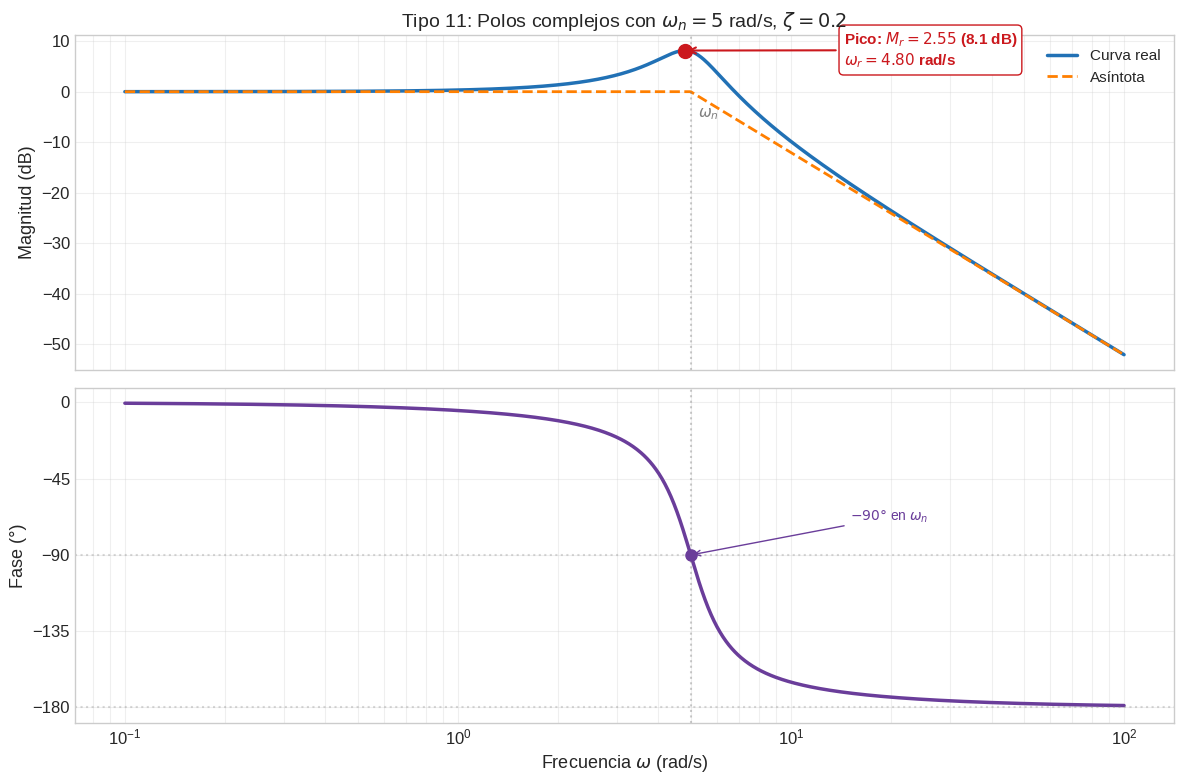

In [15]:
# Tipo 11: Ejemplo Bode con polos complejos - wn=5, zeta=0.2
wn = 5.0
zeta = 0.2
num = [wn**2]
den = [1, 2*zeta*wn, wn**2]
sys_comp = signal.TransferFunction(num, den)

w = np.logspace(-1, 2, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_comp, w)

# Asíntota
asint = np.where(w_b <= wn, 0, -40 * np.log10(w_b / wn))

# Pico de resonancia teórico
Mr = 1 / (2 * zeta * np.sqrt(1 - zeta**2))
Mr_db = 20 * np.log10(Mr)
wr = wn * np.sqrt(1 - 2*zeta**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_b, asint, color=COLOR_ASINTOTA, lw=2, ls='--', label='Asíntota')
ax1.plot(wr, Mr_db, 'o', color=COLOR_RECTA, ms=10, zorder=5)
ax1.annotate(f'Pico: $M_r = {Mr:.2f}$ ({Mr_db:.1f} dB)\n$\\omega_r = {wr:.2f}$ rad/s',
             xy=(wr, Mr_db), xytext=(wr*3, Mr_db-3),
             fontsize=11, color=COLOR_RECTA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5),
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))
ax1.axvline(x=wn, color='gray', ls=':', alpha=0.4)
ax1.text(wn*1.05, -5, r'$\omega_n$', fontsize=11, color='gray')
ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Tipo 11: Polos complejos con $\omega_n = 5$ rad/s, $\zeta = 0.2$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(w_b, fase_deg, color=COLOR_FASE, lw=2.5)
ax2.axhline(y=-90, color='gray', ls=':', alpha=0.3)
ax2.axhline(y=-180, color='gray', ls=':', alpha=0.3)
ax2.axvline(x=wn, color='gray', ls=':', alpha=0.4)
ax2.plot(wn, -90, 'o', color=COLOR_FASE, ms=8, zorder=5)
ax2.annotate(r'$-90°$ en $\omega_n$', xy=(wn, -90), xytext=(wn*3, -70),
             fontsize=10, color=COLOR_FASE,
             arrowprops=dict(arrowstyle='->', color=COLOR_FASE))
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.set_yticks([0, -45, -90, -135, -180])
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.12 Tipo 12: Bode con múltiples ceros y polos

**Método:** Aplicar la técnica del Tipo 1, pero con más elementos. Ejemplo:

$$G(s) = \frac{50(s+2)}{(s+0.5)(s+10)(s+50)}$$

**Paso 1:** Forma estándar:

$$G(s) = \frac{50 \cdot 2 \cdot (0.5s + 1)}{0.5 \cdot 10 \cdot 50 \cdot (2s+1)(0.1s+1)(0.02s+1)} = \frac{100}{250} \cdot \frac{(0.5s+1)}{(2s+1)(0.1s+1)(0.02s+1)} = 0.4 \cdot \frac{(0.5s+1)}{(2s+1)(0.1s+1)(0.02s+1)}$$

**Paso 2:** $K = 0.4$ $\to$ $20\log(0.4) = -7.96$ dB

**Paso 3:** Frecuencias de corte:

| $\omega_c$ | Tipo | Efecto |
|------------|------|--------|
| $0.5$ rad/s | Polo ($\tau = 2$) | $-20$ dB/dec |
| $2$ rad/s | Cero ($\tau = 0.5$) | $+20$ dB/dec |
| $10$ rad/s | Polo ($\tau = 0.1$) | $-20$ dB/dec |
| $50$ rad/s | Polo ($\tau = 0.02$) | $-20$ dB/dec |

**Pendiente acumulada:** $0 \to -20 \to 0 \to -20 \to -40$ dB/dec

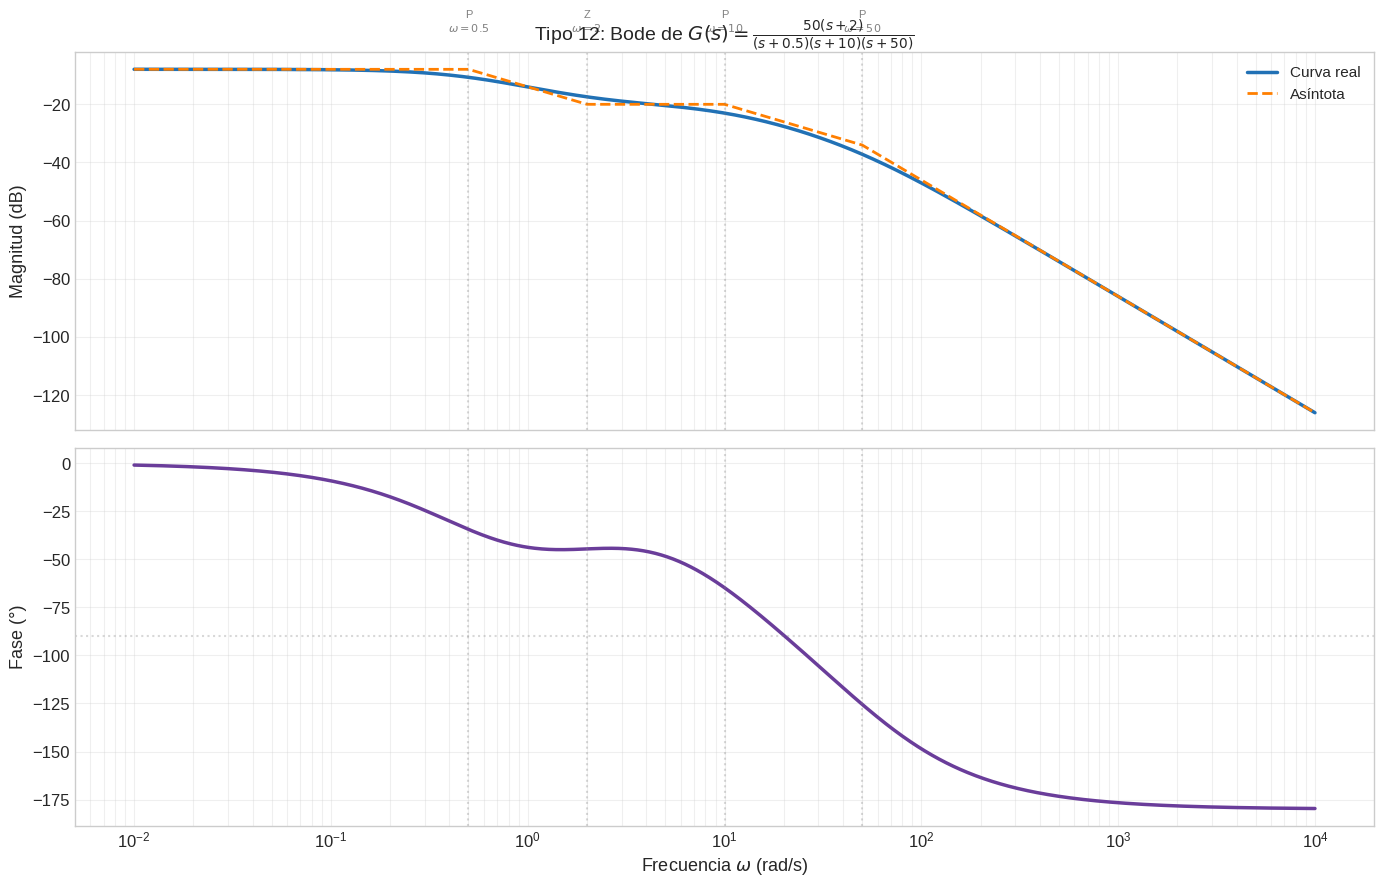

In [16]:
# Tipo 12: Bode de G(s) = 50(s+2) / [(s+0.5)(s+10)(s+50)]
num = [50, 100]  # 50*(s+2)
den = np.polymul(np.polymul([1, 0.5], [1, 10]), [1, 50]).tolist()
sys_t12 = signal.TransferFunction(num, den)

w = np.logspace(-2, 4, 1000)
w_b, mag_db, fase_deg = signal.bode(sys_t12, w)

# Asíntotas
K_db = 20 * np.log10(0.4)
asint = np.zeros_like(w_b)
for i, wi in enumerate(w_b):
    val = K_db
    if wi > 0.5:  val -= 20 * np.log10(wi / 0.5)  # polo
    if wi > 2:    val += 20 * np.log10(wi / 2)     # cero
    if wi > 10:   val -= 20 * np.log10(wi / 10)    # polo
    if wi > 50:   val -= 20 * np.log10(wi / 50)    # polo
    asint[i] = val

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.semilogx(w_b, mag_db, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
ax1.semilogx(w_b, asint, color=COLOR_ASINTOTA, lw=2, ls='--', label='Asíntota')

for wc, tipo in [(0.5, 'P'), (2, 'Z'), (10, 'P'), (50, 'P')]:
    ax1.axvline(x=wc, color='gray', ls=':', alpha=0.3)
    ax1.text(wc, 5, f'{tipo}\n$\\omega={wc}$', fontsize=8, ha='center', color='gray')

ax1.set_ylabel(r'Magnitud (dB)')
ax1.set_title(r'Tipo 12: Bode de $G(s) = \frac{50(s+2)}{(s+0.5)(s+10)(s+50)}$')
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(w_b, fase_deg, color=COLOR_FASE, lw=2.5)
for wc in [0.5, 2, 10, 50]:
    ax2.axvline(x=wc, color='gray', ls=':', alpha=0.3)
ax2.axhline(y=-90, color='gray', ls=':', alpha=0.3)
ax2.set_xlabel(r'Frecuencia $\omega$ (rad/s)')
ax2.set_ylabel(r'Fase (°)')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10. Tablas resumen

### Bloques básicos del diagrama de Bode

| Bloque | Magnitud asintótica | Fase | Observaciones |
|--------|--------------------|----- |---------------|
| $K$ ($K > 0$) | $20\log K$ dB (horizontal) | $0°$ | Desplaza verticalmente todo el Bode |
| $K$ ($K < 0$) | $20\log|K|$ dB | $-180°$ | Invierte la señal |
| $1/s$ | $-20$ dB/dec, 0 dB en $\omega=1$ | $-90°$ | Pendiente inicial si hay integrador |
| $1/s^2$ | $-40$ dB/dec | $-180°$ | Doble integrador |
| $\dfrac{1}{\tau s + 1}$ | 0 dB $\to$ $-20$ dB/dec en $\omega_c = 1/\tau$ | $0° \to -90°$ | Error $-3$ dB en $\omega_c$ |
| $\tau s + 1$ | 0 dB $\to$ $+20$ dB/dec en $\omega_c = 1/\tau$ | $0° \to +90°$ | Error $+3$ dB en $\omega_c$ |
| Polos complejos | 0 dB $\to$ $-40$ dB/dec en $\omega_n$ | $0° \to -180°$ | Pico si $\zeta < 0.707$ |
| $e^{-Ts}$ | Sin efecto | $-T\omega$ rad | Solo afecta fase |

### Fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $|G(j\omega)|_{\text{dB}} = 20\log_{10}|G(j\omega)|$ | Conversión a decibelios |
| $|j\omega + a| = \sqrt{a^2 + \omega^2}$ | Magnitud de cada factor |
| $\angle(j\omega + a) = \arctan(\omega/a)$ | Fase de cada factor |
| $M_r = \dfrac{1}{2\zeta\sqrt{1-\zeta^2}}$ | Pico de resonancia |
| $\omega_r = \omega_n\sqrt{1 - 2\zeta^2}$ | Frecuencia de resonancia |
| $\text{MG} = -|G(j\omega_{cf})|_{\text{dB}}$ | Margen de ganancia |
| $\text{MF} = 180° + \angle G(j\omega_{cg})$ | Margen de fase |
| $\omega_{cf} = \sqrt{ab}$ (para $K/[s(s+a)(s+b)]$) | Cruce de fase |

### Errores frecuentes

| Error | Corrección |
|-------|------------|
| No normalizar a forma $\tau s + 1$ | Siempre dividir para que el término independiente sea 1 |
| Olvidar sumar las contribuciones de fase | Cada polo/cero/integrador contribuye a la fase total |
| Confundir dB/dec con dB/oct | 1 década = factor 10 en $\omega$; 1 octava = factor 2 |
| Ignorar el retardo en la fase | El retardo no afecta magnitud pero degrada la fase linealmente |
| Usar pendiente $-20$ dB/dec para polos complejos | Polos complejos: $-40$ dB/dec (son dos polos) |